In [1]:
import numpy as np
import pandas as pd 
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")



import os
for dirname, _, filenames in os.walk('/kaggle/input/intel-image-classification/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

os.makedirs("outputs", exist_ok=True)




Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


 ## PyTorch Tensors

### Q1

In [2]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

tensors = [a, b, c]

for tensor in tensors:
    print(f'''
    {tensor.name}
    Shape: {tensor.shape}
    dtype: {tensor.dtype}
    device: {tensor.device}''')


    None
    Shape: torch.Size([2, 3])
    dtype: torch.float32
    device: cpu

    None
    Shape: torch.Size([2, 3])
    dtype: torch.float32
    device: cpu

    None
    Shape: torch.Size([4])
    dtype: torch.float32
    device: cpu


Tensors are all using the CPU for the device type, if there was a mismatch for device types it would cause a run time error.

### Q2

In [3]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])
print(x)
x_sum = x.sum()
x_mean=x.mean()
x_argmax= torch.argmax(x)
print(f'''
    mean: {x_mean}
    sum: {x_sum}
    argmax: {x_argmax}
    ''')
for value in x:
    sqrt=torch.sqrt(value)
    print(f'{value} SQRT: {sqrt}')
#argmax method in torch returns the index of the value with the max value
#if given the output for 1000 classes the argmax value would return the index of the highest logit amougst the classes

tensor([ 1.,  4.,  9., 16., 25.])

    mean: 11.0
    sum: 55.0
    argmax: 4
    
1.0 SQRT: 1.0
4.0 SQRT: 2.0
9.0 SQRT: 3.0
16.0 SQRT: 4.0
25.0 SQRT: 5.0


###Q3

In [4]:
for tensor in tensors:
    tensor_gpu = tensor.to(device)
    print(f"device: {tensor_gpu.device}")
    
    tensor_back  = tensor_gpu.cpu()
    tensor_numpy = tensor_back.numpy()
    print(f"numpy type: {type(tensor_numpy)}")
    print(f"numpy values:\n{tensor_numpy}\n")

#tensors have to be converted back into CPU because that is where numpy numbers operate on the CPU memory
#Numpy arrays live on the CPU

device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]

device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[0. 0. 0.]
 [0. 0. 0.]]

device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[1. 1. 1. 1.]



###Q4

In [5]:
t = torch.arange(24).float()
print(t.shape)
t_2=t.reshape(4,6)
print(f'4, 6 Reshape {t_2.shape}')
t_3=t.reshape(2, 3, 4)
print(f'2, 3, 4 Reshape {t_3.shape}')
t_plus_1d= torch.unsqueeze(t_2, dim=0)
print(t_plus_1d.shape)
#unsqueeze(0) adds a batch dimension and can be used to add batch size to tensors for neural network processing
#This method is used during the validation step for Transfer Learning, where the correctness of individual images are returned

torch.Size([24])
4, 6 Reshape torch.Size([4, 6])
2, 3, 4 Reshape torch.Size([2, 3, 4])
torch.Size([1, 4, 6])


### Q5

In [6]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a  = torch.tensor(np_a, dtype=torch.float32)
t_b  = torch.tensor(np_b, dtype=torch.float32)

np_multipcation= np_a * np_b
pytorch_multipcation= t_a * t_b
print(np_multipcation)
print(pytorch_multipcation)
#dimentionality of the matrices have to match before multiplying this makes sure the functions like the 
#activation function are apple to operate on tensors as ecxpected

[[ 5. 12.]
 [21. 32.]]
tensor([[ 5., 12.],
        [21., 32.]])


## Model Questions

### Q1

In [7]:
weights = ResNet18_Weights.DEFAULT
model   = models.resnet18(weights=weights)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

#Pretrained weights not only save time but they save GPU, when running the model, it does not have to start from 
#scratch finding and collecting all of the parameters that exist

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


Total parameters:     11,689,512
Trainable parameters: 11,689,512


### Q2

In [8]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Name of the final is FC with an output size of 1000--> which is the max number of categories 
Yes, it means that these blocks do not interact directly with the input or output values but are used for feature detection, categorizations, and weighting. These models learn their own internal representations from data

### Q3

In [9]:
model = model.to(device) #to device makes sure the model is running on the device(CPU or GPU) assigned earlier in code
model.eval() #eval runs the test set
print("Model ready for inference.")
# While in eval there is no learning or test evaluation, so there is no backwards pass or optimization

Model ready for inference.


### Q4

In [10]:
preprocess = weights.transforms()
print(preprocess)
#Resize makes all of the images the same size and shape, and this ensures their numerical stability during training
#The ToTensor() method converts PIL images/narrays to a tensor and scales the values accordingly
#Normalization of the input statistics align the distribution of the pretrained model, and this encourages faster learning


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Running Inference

In [11]:
import random
random.seed(42)
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR/label
    img_path  = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name


In [12]:
imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")


Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## Q1

In [13]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """
    # Step 1: Preprocess the image and add a batch dimension
    # (hint: use preprocess(), .unsqueeze(0), and .to(device))
    image_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Step 2: Run inference inside a torch.no_grad() block
    # (hint: call model() on your input tensor to get output of shape (1, 1000))

    with torch.no_grad():
        logits = model(image_tensor)



    # Step 3: Convert raw scores (logits) to probabilities
    # (hint: use torch.nn.functional.softmax on output[0])
        probs = torch.nn.functional.softmax(logits[0], dim=0)

    # Step 4: Get the top 5 predictions using torch.topk
    # (hint: returns top_probs and top_indices)
    top_probs, top_idx = probs.topk(5, dim=0)

    # Step 5: Build and return a list of (class_name, probability) tuples
    # Step 5: Build and return a list of (class_name, probability) tuples
    results = [(imagenet_classes[idx], prob) for idx, prob in zip(top_idx, top_probs)]
    return results
    pass


In [14]:
img, img_name = load_sample_image("mountain")
preds         = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"  {class_name:30s}  {prob:.4f}")


Top-5 predictions for '24204.jpg':
  alp                             0.4911
  volcano                         0.2076
  valley                          0.2016
  promontory                      0.0184
  mountain tent                   0.0169


The predication for ALP makes sense, because the look of a mountain is very similar to how the alps look, the same is true for volcano and valley. All of these landscapes have a slope and typically some type of peaks that to a computer would have similar features and look the same

### Q2

In [15]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")


[buildings]  24258.jpg
  palace                          0.4301
  gondola                         0.1305
  monastery                       0.0624

[forest]  23309.jpg
  viaduct                         0.3853
  totem pole                      0.1089
  cliff                           0.0419

[glacier]  20272.jpg
  volcano                         0.3854
  valley                          0.3297
  promontory                      0.1216

[mountain]  20662.jpg
  ski                             0.5933
  alp                             0.3821
  snowmobile                      0.0071

[sea]  23069.jpg
  seashore                        0.2016
  breakwater                      0.1834
  geyser                          0.1718

[street]  24269.jpg
  unicycle                        0.1299
  triumphal arch                  0.1268
  jinrikisha                      0.1049


The classes the model seems the most confident about is mountain with a probability of 0.59 percent probability. It is the least confident about the street. It seems like it does better on natural structures vs. man-made structures

### Q3

In [16]:
img, _ = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)
top_probs, top_idx = probs.topk(5, dim=0)

print(f"Logit  range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob   range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top prediction: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")


Logit  range: min=-4.87, max=6.61
Prob   range: min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike  (0.0979)


Logits are used to create probability as an intermediary. Based on the logits of all of the given categories then an actual probability can be determined. Logit determines the confidence for each label and the low confidence labels can be filtered out by that nature. Then, logit makes more sense for filtering out irrelevant labels, then making a probability based on the logits confidence of the most likely label

### Q4

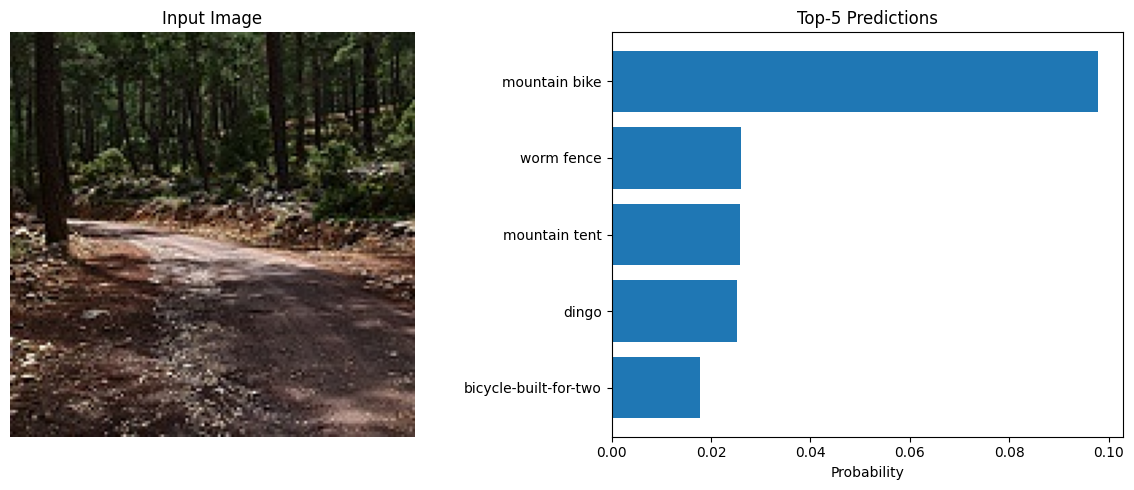

In [17]:

    results = [(imagenet_classes[idx.item()], prob.cpu().item()) for idx, prob in zip(top_idx, top_probs)]    
    labels = [r[0] for r in results]
    values = [r[1] for r in results]
    probs = top_probs.tolist()  # convert tensor → list

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title("Input Image")
    
    axes[1].barh(labels[::-1], values[::-1])
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Top-5 Predictions")

    plt.tight_layout()
    plt.show()

This dashboard could be optimized by also showing some of the training images. This would help the non technical person give feedback on the types of images that need to be addee to bolster the accuracy of the training data